# Data Preparation (Preparação dos dados)

## Biblioteca / Configuração

In [31]:
# Dependências
import sys
#!{sys.executable} -m pip install --disable-pip-version-check -r ../requirements.txt -q
print('Bibliotecas instaladas')

Bibliotecas instaladas


In [32]:
# Acesso aos modulos do diretório
from pathlib import Path
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT)) 

# Manipulação dos dados
import pandas as pd
import numpy as np
import pickle

# Visualização dos dados
import matplotlib.pyplot as plt
import seaborn as sns

# Diretórios
from configs.paths import *
from configs.function_basic import *

# Modelos / Machine Learning
from sklearn.ensemble import ExtraTreesClassifier

# Avisos
import warnings
warnings.filterwarnings('ignore')

# Configuração
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
pd.set_option('display.width', None)

print('Ambiente Configurado')

Ambiente Configurado


## Parâmetros Globais

In [33]:
# define a coluna alvo do modelo
TARGET = 'FPD'
# garante reprodutibilidade dos experimentos
RANDOM_STATE = 42
# percentual máximo de valores ausentes permitido para manter a variável
PERCENTUAL_MAX_FALTANTES = 20
# quantidade de features mais relevantes a considerar
TOP_N_FEATURES = 30

## Carregamento dos dados 

In [34]:
# Carregar dados CORRIGIDOS conforme solicitado
train = pd.read_parquet(PROCESSED_DIR / 'abt01_train.parquet')
test = pd.read_parquet(PROCESSED_DIR / 'abt01_test.parquet')

print(f'📊 Treino: {train.shape}')
print(f'📊 Teste: {test.shape}')
print(f'\n🎯 Distribuição do Target (Treino):')
print(f"  Treino: {(train[TARGET].value_counts(normalize=True) * 100).round(2)}")

📊 Treino: (873093, 123)
📊 Teste: (407735, 123)

🎯 Distribuição do Target (Treino):
  Treino: 0    76.2
1    23.8
Name: FPD, dtype: float64


## Preparação dos Dados

In [35]:
train

,SCORE_02,SCORE_DIFF,var_03,var_09,var_25,CEP_3_digitos,IDADE,REGIAO_POSTAL,SUB_REGIAO_POSTAL,REGIAO_POSTAL_TXT,TEMPO_CADASTRO,AUX_EMRG,FUNC_PRIVADO,var_26,var_27,var_28,var_29,var_30,var_31,var_32,var_33,var_34,var_35,var_36,var_37,var_38,var_39,var_40,var_41,var_42,var_43,var_44,var_45,var_46,var_47,var_48,var_49,var_50,var_51,var_52,var_53,var_54,var_55,var_56,var_57,var_58,var_59,var_60,var_61,var_62,var_63,var_64,var_65,var_66,var_67,var_68,var_69,var_70,var_71,var_72,var_73,var_74,var_75,var_76,var_77,var_78,var_79,var_80,var_81,var_82,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_90,var_91,var_92,var_93,QTDE_RECARGAS,QTDE_NUMEROS,VAL_CREDITO_INSERIDO,VAL_BONUS,VAL_REAL,TICKET_MEDIO_RECARGA,RATIO_BONUS_CREDITO,RATIO_REAL_CREDITO,FLAG_MULTI_NUMERO,QTDE_RECARGAS_ULT_1_SAFRAS,QTDE_RECARGAS_ULT_3_SAFRAS,QTDE_RECARGAS_ULT_6_SAFRAS,QTDE_NUMEROS_ULT_1_SAFRAS,QTDE_NUMEROS_ULT_3_SAFRAS,QTDE_NUMEROS_ULT_6_SAFRAS,VAL_CREDITO_INSERIDO_ULT_1_SAFRAS,VAL_CREDITO_INSERIDO_ULT_3_SAFRAS,VAL_CREDITO_INSERIDO_ULT_6_SAFRAS,VAL_BONUS_ULT_1_SAFRAS,VAL_BONUS_ULT_3_SAFRAS,VAL_BONUS_ULT_6_SAFRAS,VAL_REAL_ULT_1_SAFRAS,VAL_REAL_ULT_3_SAFRAS,VAL_REAL_ULT_6_SAFRAS,var_04_1,var_04_2,var_04_3,var_04_4,var_04_5,var_05_10,var_05_2,var_05_3,var_05_4,var_05_5,var_05_6,var_05_7,var_05_8,var_05_9,var_05_Desconhecido,var_24_DISPENSADO,var_24_Desconhecido,FPD
0,636.0,74.0,27,15,50,479,40,4,46,0,15,0,1,1.0,1.0,71.43,24.49,72.43,93.62,51.45,45.54,27.40,23.01,304.00,304.00,304.00,304.00,27.78,61.91,87.64,68.58,25.92,76.16,46.21,100.00,20.38,100.0,4.44,0.00,0.00,11.92,49.85,87.98,99.59,100.0,100.00,33.33,0.65,90.91,94.93,76.07,98.14,0.0,37.99,96.40,96.95,48.90,100.00,304.0,100.0,0.0,304.0,304.0,304.0,0.0,304,304,304,304,304.00,304,304,304,2,3,1,50,0.86,2,1,1,1.0,1.0,30.0,0.0,30.0,20.000000,0.0,1.0,0.0,2.0,5.0,9.0,1.0,3.0,6.0,30.0,90.0,175.0,0.0,0.0,0.0,30.0,100.13,205.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,518.0,-28.0,6,15,50,690,43,6,68,7,4,0,1,1.0,0.0,78.25,24.49,0.00,100.00,0.00,0.00,304.00,304.00,304.00,304.00,304.00,304.00,0.19,1.05,5.99,5.99,0.24,76.16,35.84,90.91,94.56,100.0,91.67,0.00,0.00,0.09,48.64,24.49,100.00,100.0,100.00,100.00,4.66,0.00,2.50,0.00,0.00,0.0,9.97,46.21,0.00,53.79,100.00,304.0,304.0,0.0,304.0,304.0,304.0,0.0,304,304,304,304,304.00,304,304,304,304,304,304,304,304.00,304,304,304,2.0,1.0,40.0,0.0,40.0,20.000000,0.0,1.0,0.0,3.0,7.0,9.0,1.0,3.0,5.0,40.0,117.0,147.0,0.0,0.0,20.0,40.0,117.00,167.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,750.0,129.0,27,15,58,790,42,7,78,1,13,0,1,1.0,1.0,75.75,80.93,95.02,0.00,100.00,99.99,100.00,99.96,6.19,66.40,73.59,35.97,99.96,100.00,81.44,76.16,77.83,76.16,46.21,100.00,96.56,100.0,11.58,0.00,0.00,1.80,0.00,55.46,100.00,100.0,100.00,39.83,100.00,85.37,99.77,60.00,58.28,0.0,83.37,95.02,70.12,52.53,100.00,100.0,100.0,0.0,304.0,304.0,304.0,0.0,304,304,304,304,304.00,304,304,304,0,1,1,100,298.00,1,1,2,1.0,1.0,25.0,0.0,25.0,25.000000,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,25.0,25.0,25.0,0.0,0.0,0.0,25.0,25.00,25.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,679.0,70.0,46,14,30,691,36,6,68,7,8,1,0,1.0,1.0,0.00,304.00,52.51,0.00,98.56,97.21,66.23,58.11,304.00,304.00,304.00,304.00,85.75,99.70,304.00,304.00,304.00,0.00,0.00,304.00,0.00,0.0,0.00,304.00,304.00,88.08,81.25,35.84,0.00,75.0,19.36,304.00,304.00,100.00,80.93,78.56,99.98,0.0,46.21,87.01,99.93,44.29,91.67,25.0,100.0,0.0,304.0,304.0,304.0,0.0,0,1,6,100,298.00,1,1,2,304,304,304,304,304.00,304,304,304,3.0,2.0,50.0,20.0,70.0,16.666667,0.4,1.4,1.0,4.0,7.0,10.0,1.0,3.0,6.0,85.0,160.0,235.0,0.0,0.0,0.0,85.0,160.00,235.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
4,722.0,101.0,27,15,50,758,40,7,74,1,6,0,1,1.0,1.0,29.57,12.44,95.40,0.00,100.00,100.00,59.19,45.12,58.27,53.70,56.75,25.20,72.93,96.51,29.13,25.43,4.30,76.16,24.49,100.00,8.65,32.5,3.57,88.29,1.14,11.92,54.62,80.93,99.93,100.0,100.00,35.81,94.47,77.50,98.01,100.00,98.14,0.0,95.62,98.4

In [36]:
# Separar features e target
X_train = train.drop(TARGET, axis=1)
y_train = train[TARGET]

X_test = test.drop(TARGET, axis=1)
y_test = test[TARGET]

print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')

# Garantir mesmas features em treino e teste
features_common = X_train.columns.intersection(X_test.columns)
X_train = X_train[features_common]
X_test = X_test[features_common]

print(f'\n✅ Features alinhadas: {len(features_common)}')

X_train: (873093, 122)
X_test: (407735, 122)

✅ Features alinhadas: 122


### Seleção de Variaveis

In [37]:
# Aplicando no treino
train_fs = X_train

# define X e y para treino
X_train = train_fs
y_train = train[TARGET] 

In [38]:
# Inicializa ExtraTrees para ranking de features
clf = ExtraTreesClassifier(n_estimators=500, max_depth=None, min_samples_leaf=10,
                           random_state=RANDOM_STATE, n_jobs=-1)  # n_jobs=-1 usa todos os núcleos

# Treina o modelo
clf.fit(X_train, y_train)  # ajusta o modelo aos dados

# Cria DataFrame com features e importâncias
feat_imp = pd.DataFrame({"feature": X_train.columns, "importance": clf.feature_importances_}) \
            .sort_values(by="importance", ascending=False)  # ordena por importância

# Seleciona top N features mais relevantes
selected_features_fs = feat_imp.head(TOP_N_FEATURES)["feature"].tolist()  # lista de features
selected_features_df = feat_imp.head(TOP_N_FEATURES)  # DataFrame com top features

# Exibe quantidade de features selecionadas
print(f"Número de features selecionadas: {len(selected_features_fs)}")

Número de features selecionadas: 30


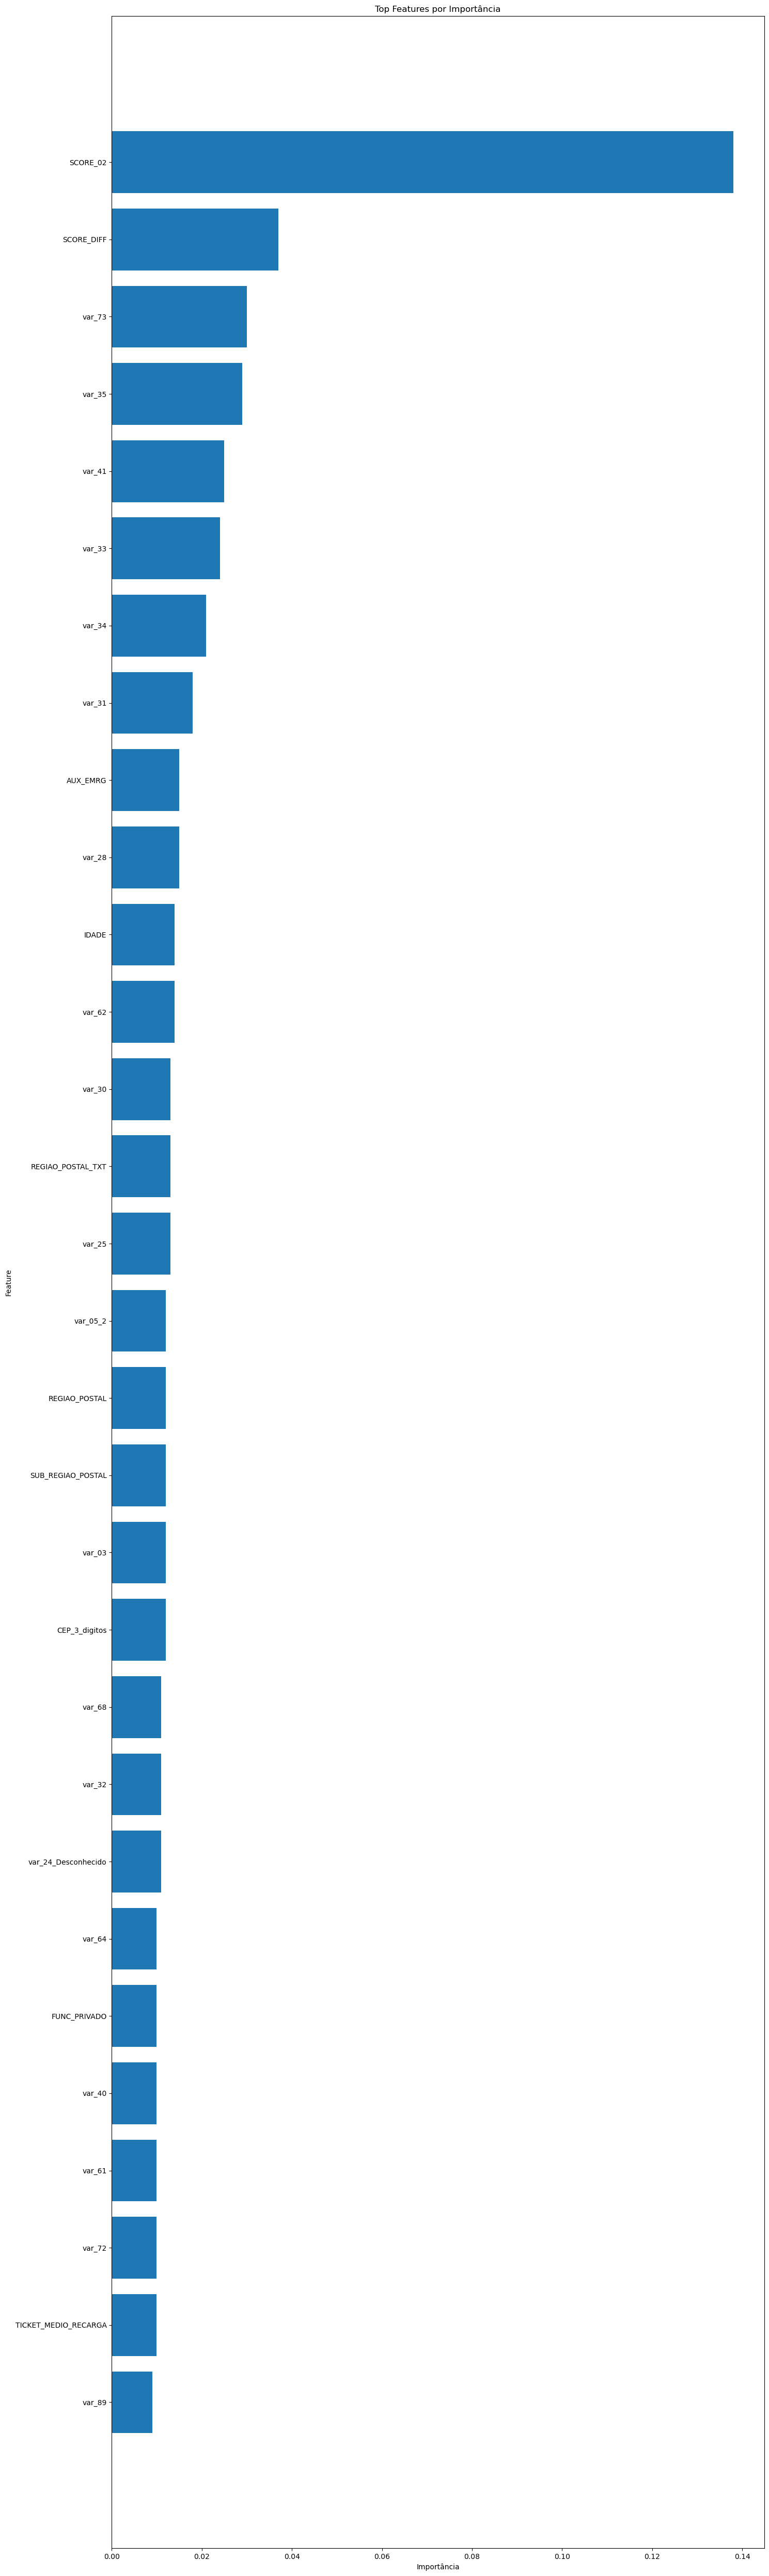

In [39]:
# Formata as importâncias com 3 casas decimais
feat_imp_table = feat_imp.sort_values(by="importance", ascending=False)
feat_imp_table["importance"] = feat_imp_table["importance"].round(3)

# Plotar importância das features (top N)
top_feats = feat_imp_table.head(TOP_N_FEATURES)

plt.figure(figsize=(15, 50))
plt.barh(top_feats['feature'], top_feats['importance'])
plt.gca().invert_yaxis()  # feature mais importante no topo
plt.title('Top Features por Importância')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [40]:
# Manter no X_train apenas as colunas selecionadas
X_train = X_train[selected_features_fs].copy()

### Correlação

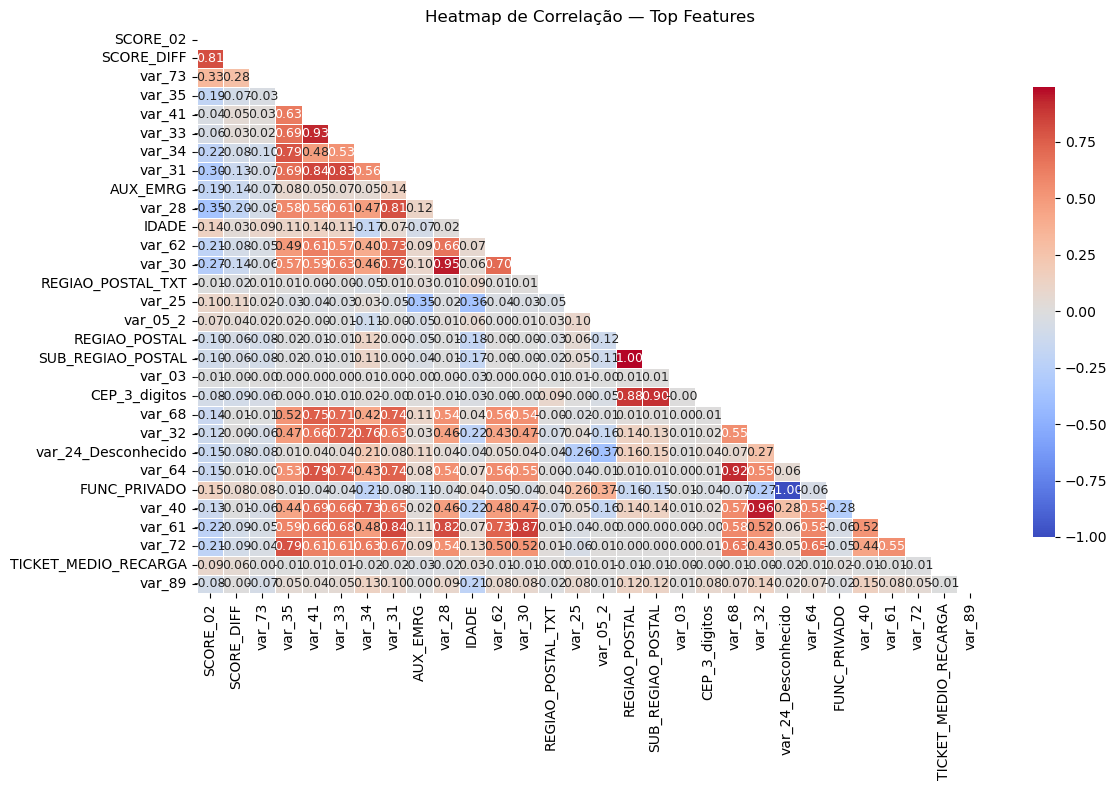

In [41]:
# calcula correlação apenas dessas features numéricas
corr = X_train.select_dtypes(include='number').corr()

# máscara para mostrar só metade da matriz
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 9},
    cbar_kws={"shrink": 0.8}
)

plt.title("Heatmap de Correlação — Top Features")
plt.tight_layout()
plt.show()


In [47]:
# Identificar pares de features com correlação absoluta acima do limiar

# calcula correlação apenas dessas features numéricas ignorando sinais
corr = X_train.select_dtypes(include='number').corr().abs()

# evita pares duplicados e remove a diagonal principal
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# percorre a matriz filtrada para encontrar pares altamente correlacionados
high_corr_pairs = [
    (row, col, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if upper.loc[row, col] > 0.8
]

# lista final de pares com alta correlação
high_corr_pairs

[('SCORE_02', 'SCORE_DIFF', 0.8097517457579889),
 ('var_41', 'var_31', 0.840291207785091),
 ('var_31', 'var_28', 0.8064752548264033),
 ('var_31', 'var_61', 0.8361787144933835),
 ('var_28', 'var_61', 0.8219424434656812)]

In [48]:
# Remover a feature menos importante entre pares altamente correlacionados

# Conjunto para armazenar features marcadas para remoção (evita duplicidade)
to_drop = set()

# percorre cada par de features com alta correlação
for f1, f2, _ in high_corr_pairs:
    
    # recupera a importância da primeira feature
    imp_f1 = feat_imp_table.loc[
        feat_imp_table['feature'] == f1, 'importance'
    ].values[0]
    
    # recupera a importância da segunda feature
    imp_f2 = feat_imp_table.loc[
        feat_imp_table['feature'] == f2, 'importance'
    ].values[0]

    # compara importâncias e marca para remoção a menos relevante
    if imp_f1 < imp_f2:
        to_drop.add(f1)
    else:
        to_drop.add(f2)

# lista final de features sugeridas para remoção
list(to_drop)

['var_28', 'var_31', 'SCORE_DIFF', 'var_61']

In [49]:
# Drop de colunas redundantes ou sem importância para feature selection
cols_to_drop = to_drop
X_train = X_train.drop(columns=cols_to_drop)

In [50]:
X_train.shape

(873093, 19)

## Salvamento dos Dados Processados

In [51]:
# Salvar lista de features (excluindo a target) para referência futura
selected_features = [c for c in X_train.columns if c != TARGET]
with open(ARTIFACT_DIR / 'selected_features.pkl', 'wb') as f:
    pickle.dump(selected_features, f)

print(f'   ✓ Lista de features salva em: {ARTIFACT_DIR / "selected_features.pkl"}')
print(f'\n✅ Todos os dados processados foram salvos')


   ✓ Lista de features salva em: C:\pod\hackathon_pod_2025\ciencia\artifact\selected_features.pkl

✅ Todos os dados processados foram salvos
